![image.png](https://i.imgur.com/a3uAqnb.png)

# **Build a Dataset Class for Horse Breeds**

https://www.kaggle.com/datasets/olgabelitskaya/horse-breeds

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olgabelitskaya/horse-breeds")

print("Path to dataset files:", path)

100%|██████████| 82.0M/82.0M [00:00<00:00, 110MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/olgabelitskaya/horse-breeds/versions/27


#### Optional: You can explore more datasets types like TensorDataset, StackDataset here: [Link](https://pytorch.org/docs/stable/data.html#torch.utils.data.TensorDataset)

In [ ]:
from PIL import Image
import os
from torchvision import transforms
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
from tqdm import tqdm
import torch.optim as optim


### Dataset Class

In [ ]:
LABEL_MAP = {
            "01": "Akhal-Teke",
            "02": "Appaloosa",
            "03": "Orlov Trotter",
            "04": "Vladimir Heavy Draft",
            "05": "Percheron",
            "06": "Arabian",
            "07": "Friesian",}

In [ ]:


class HorseDataset(Dataset):
    def __init__(self, root_dir,label_map, transform=None):

        self.root_dir = root_dir
        self.transform = transform
        self.label_map = label_map

        # image paths and corresponding labels
        self.samples = []
        for fname in os.listdir(root_dir):
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                prefix = fname[:2]
                if prefix in self.label_map:
                    label = prefix  # numeric label
                    self.samples.append((os.path.join(root_dir, fname), label))

        # Map prefixes to integer classes (for training)
        self.class_to_idx = {k: i for i, k in enumerate(self.label_map.keys())}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, prefix = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.class_to_idx[prefix]

        if self.transform:
            image = self.transform(image)

        return image, label

### Transforms

In [ ]:
# Define transformations (resize, tensor conversion, normalization, etc.)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

### Create dataset object

In [ ]:
dataset = HorseDataset(root_dir= path,label_map= LABEL_MAP, transform=transform)

img, label = dataset[0]
print(img.shape, label)

torch.Size([3, 224, 224]) 6


### Split the data into train and test set

In [ ]:
# Define split sizes (80% train, 20% validation)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_size, val_size

(536, 134)

#### Check dataset size


In [ ]:
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

Train samples: 536, Val samples: 134


### Create Dataloader objects

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

for imgs, labels in train_loader:
    print(len(imgs), labels)
    break

32 tensor([4, 5, 1, 2, 2, 2, 1, 3, 6, 5, 6, 1, 1, 6, 5, 5, 1, 1, 6, 0, 6, 2, 1, 1,
        1, 6, 1, 1, 3, 6, 0, 6])


### Check the dataset shape


In [ ]:
print("Shape of one image tensor:", imgs[0].shape)

Shape of one image tensor: torch.Size([3, 224, 224])


#### Display some images

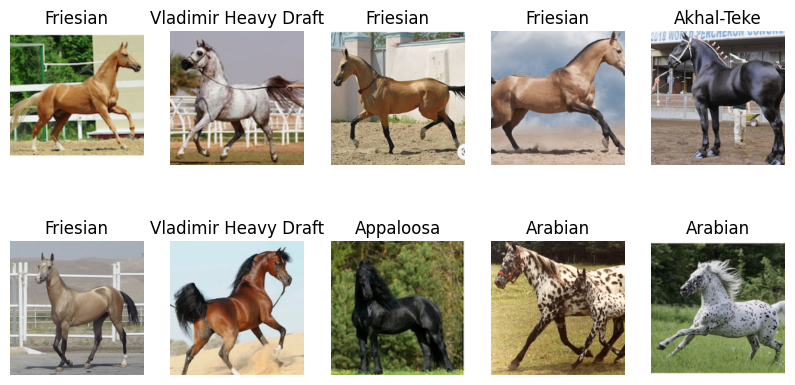

In [ ]:
# Get a batch of training data
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Show images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    img = images[i]
    img = np.transpose(img.numpy(), (1, 2, 0))  # Convert (C, H, W) to (H, W, C)
    classes = ['Friesian', 'Arabian', 'Percheron', 'Orlov Trotter', 'Akhal-Teke',
               'Vladimir Heavy Draft', 'Appaloosa']
    ax.imshow(img)
    ax.set_title(classes[labels[i]])
    ax.axis("off")

plt.show()

# **Build a classifier model using pretrained model**

**Hint: use the pretrained EfficientNet-B0 model**

### Load pretrained EfficientNet-B0 and modify the classifier based on the given dataset

In [ ]:
from torchvision import models

# Load pretrained EfficientNet-B0
model = models.efficientnet_b0(pretrained=True)

# Modify the classifier for binary classification (cats vs. dogs)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10)  # 10 classes

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 109MB/s] 


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

### Training loop

In [ ]:

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader):
        images, labels = images.to(device), labels.to(device)


        outputs = model(images)#.squeeze()  # The model outputs in shape [batch_size,1]. We convert them to [batch_size,] so the loss accepts them.
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Track accuracy
        predictions = torch.sigmoid(outputs) > 0.5  # Get predicted class
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy


### Validation Loop

In [ ]:
def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images).squeeze()  # The model outputs in shape [batch_size,1]. We convert them to [batch_size,] so the loss accepts them.
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            # Compute accuracy
            predictions = torch.sigmoid(outputs) > 0.5  # Get predicted class
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

### Running Training

In [ ]:
criterion = nn.CrossEntropyLoss()  # Binary Classification loss (Use when there is no softmax/sigmoid in the last layer)
optimizer = optim.Adam(model.parameters(), lr=0.0001)  # Adam optimizer
num_epochs = 10 # Number of epochs


# Lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [ ]:
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images).squeeze()  # The model outputs in shape [batch_size,1]. We convert them to [batch_size,] so the loss accepts them.
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Track accuracy
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_accuracy = 100 * correct / total


    model.eval()
    eval_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validating"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            eval_loss += loss.item()

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    val_loss = eval_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Accuracy={train_accuracy:.2f}%, "
          f"Val Loss={val_loss:.4f}, Val Accuracy={val_accuracy:.2f}%")

Validating: 100%|██████████| 5/5 [00:00<00:00,  5.19it/s]


Epoch 1/10: Train Loss=2.0880, Train Accuracy=36.57%, Val Loss=1.7910, Val Accuracy=64.18%


Validating: 100%|██████████| 5/5 [00:00<00:00,  6.08it/s]


Epoch 2/10: Train Loss=1.4761, Train Accuracy=78.73%, Val Loss=1.1784, Val Accuracy=78.36%


Validating: 100%|██████████| 5/5 [00:00<00:00,  6.10it/s]


...

Epoch 8/10: Train Loss=0.1107, Train Accuracy=99.63%, Val Loss=0.3836, Val Accuracy=90.30%


Validating: 100%|██████████| 5/5 [00:00<00:00,  5.27it/s]


Epoch 9/10: Train Loss=0.0968, Train Accuracy=99.81%, Val Loss=0.4088, Val Accuracy=87.31%


Validating: 100%|██████████| 5/5 [00:00<00:00,  6.14it/s]

Epoch 10/10: Train Loss=0.0630, Train Accuracy=99.63%, Val Loss=0.3999, Val Accuracy=89.55%


 ### Plot loss and accuracy for training and validation

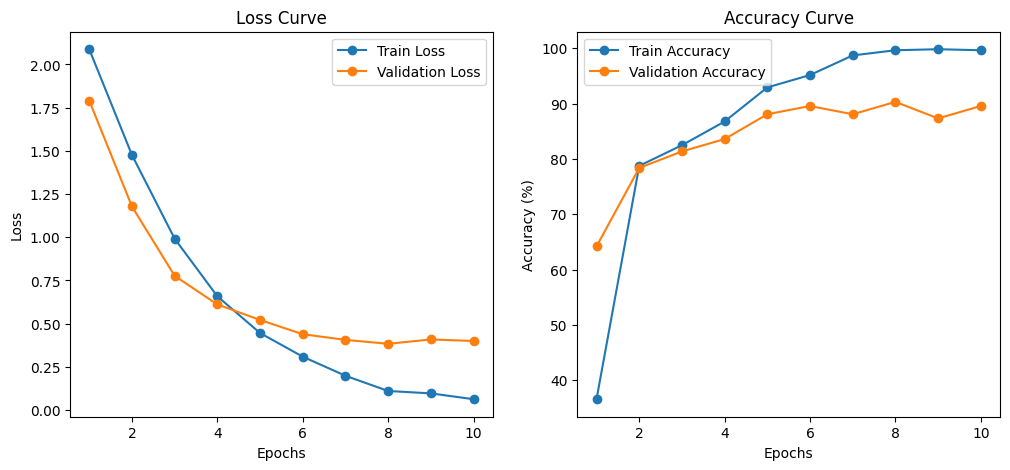

In [ ]:
import matplotlib.pyplot as plt

# Plot loss curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot accuracy curve
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, num_epochs+1), val_accuracies, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.show()


### Display sample of predictions

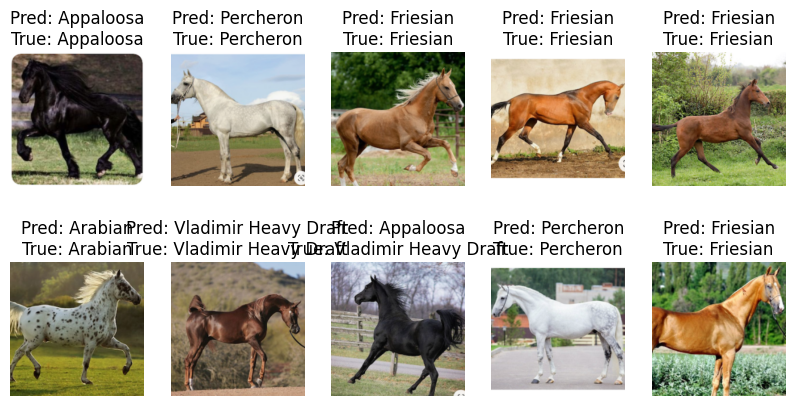

In [ ]:
import numpy as np

# Function to display images with predicted labels
def show_predictions(model, dataloader, device, num_images=10):
    model.eval()  # Set to evaluation mode
    images, labels = next(iter(dataloader))  # Get a batch
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():  # Disable gradient computation
        outputs = model(images)
        predictions = outputs.argmax(dim=1)  # Get predicted class

    classes = ['Friesian', 'Arabian', 'Percheron', 'Orlov Trotter', 'Akhal-Teke',
               'Vladimir Heavy Draft', 'Appaloosa']

    # Plot images with predictions
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for i, ax in enumerate(axes.flat[:num_images]):
        img = images[i]
        img = np.transpose(img.cpu().numpy(), (1, 2, 0))  # Convert to (H, W, C)

        ax.imshow(img)
        ax.set_title(f"Pred: {classes[predictions[i].item()]}\nTrue: {classes[labels[i].item()]}")
        ax.axis("off")

    plt.show()

# Show predictions
show_predictions(model, val_loader, device)
